In [ ]:
%pip install git+https://github.com/tatsuroyamaguchi/resonance-manifold-clustering.git

RMC (Resonance Manifold Clustering) デモ
1. データセットを生成中...
2. RMCモデルを初期化中...
3. クラスタリングを実行中...（数秒かかる場合があります）

[結果]
 発見されたクラスタ数 : 1
 ノイズ点の数         : 0
 最終反復回数         : 3000
 収束                 : 未収束

4. グラフを 'rmc_demo_plot.png' に保存します。


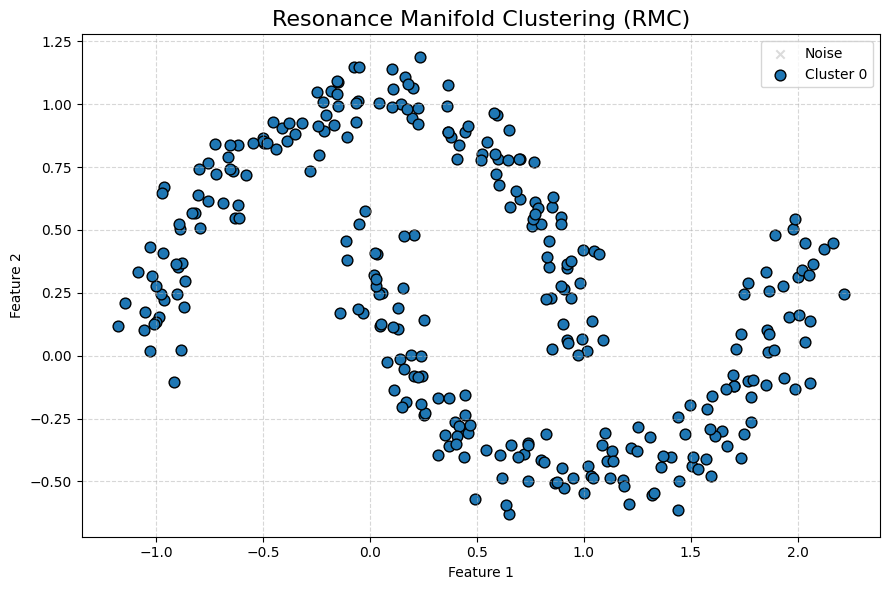

完了しました！


In [ ]:
# RMCのデモスクリプト

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from rmc import RMC

def run_demo():
    print("====================================")
    print("RMC (Resonance Manifold Clustering) デモ")
    print("====================================")

    # 1. デモ用データの生成（三日月型のデータ）
    print("1. データセットを生成中...")
    X, true_labels = make_moons(n_samples=300, noise=0.08, random_state=42)

    # 2. RMCモデルの初期化
    print("2. RMCモデルを初期化中...")
    model = RMC(
        sigma=0.3,                   # ガウスカーネルのスケール
        coupling_strength=5.0,       # 結合の強さ
        dt=0.05,                     # タイムステップ
        max_iterations=3000,         # 最大反復回数
        tol=1e-5,                    # 収束判定の閾値
        n_runs=3,                    # コンセンサス・クラスタリングの実行回数
        dbscan_eps=0.3,              # DBSCAN用のeps
        dbscan_min_samples=3,        # DBSCAN用のmin_samples
        connectivity_threshold=0.1,  # クラスタ間の弱い結合を切り離す閾値
        normalize=True,              # データの正規化あり
        random_state=42              # 再現性のための乱数シード
    )

    # 3. 学習・推論
    print("3. クラスタリングを実行中...（数秒かかる場合があります）")
    labels = model.fit_predict(X)

    # 結果の確認
    n_clusters = len(set(labels) - {-1})
    n_noise = np.sum(labels == -1)
    
    print("\n[結果]")
    print(f" 発見されたクラスタ数 : {n_clusters}")
    print(f" ノイズ点の数         : {n_noise}")
    print(f" 最終反復回数         : {model.n_iter_}")
    print(f" 収束                 : {'成功' if model.converged_ else '未収束'}")
    
    # 4. グラフに可視化
    print("\n4. グラフを 'rmc_demo_plot.png' に保存します。")
    plt.figure(figsize=(9, 6))
    
    # ノイズを描画 (ラベルが-1の点)
    noise_idx = (labels == -1)
    plt.scatter(X[noise_idx, 0], X[noise_idx, 1], c='lightgray', marker='x', label='Noise', alpha=0.8)
    
    # クラスタごとに色分けして描画
    unique_labels = list(set(labels) - {-1})
    if len(unique_labels) > 0:
        colors = plt.get_cmap('tab10', len(unique_labels))
    else:
        colors = plt.get_cmap('tab10')
    
    for i, cluster_id in enumerate(unique_labels):
        cluster_idx = (labels == cluster_id)
        plt.scatter(X[cluster_idx, 0], X[cluster_idx, 1], 
                    color=colors(i), s=60, edgecolors='k', 
                    label=f'Cluster {cluster_id}')
        
    plt.title("Resonance Manifold Clustering (RMC)", fontsize=16)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    # 画像ファイルとして保存
    plt.show()
    print("完了しました！")

if __name__ == "__main__":
    run_demo()
